In [85]:
import pandas as pd
import matplotlib.pyplot as pplot
import seaborn as sborn

In [86]:
data = pd.read_csv('archive/student-mat.csv')
see_cols = data.columns

In [87]:
'''
FEATURE SELECTIONS
NUMERICAL
[ "G1", "G2" ]

[ "absences", "Walc", "Dalc", "health", "goout", "failures", "studytime", "freetime" ]

CATEGORICAL
[ "activities", "internet", "romantic" ]
# DONE converting(yes, no) from categorical to numerical (0, 1)
'''

'\nFEATURE SELECTIONS\nNUMERICAL\n[ "G1", "G2" ]\n# DONE cleaning\n\n[ "absences", "Walc", "Dalc", "health", "goout", "failures", "studytime", "freetime" ]\n\nCATEGORICAL\n[ "activities", "internet", "romantic" ]\n# DONE converting(yes, no) from categorical to numerical (0, 1)\n'

In [88]:
missing_values = data.isnull().sum() # no missing values shown

In [89]:
data = data[(data['G3'] >= 0) & (data['G3'] <= 20)]

In [90]:
def remove_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[col] >= Q1 - 1.5 * IQR) & (data[col] <= Q3 + 1.5 * IQR)]

for col in ['G1', 'G2', 'G3']:
    data = remove_outliers(data, col)

data = data.reset_index(drop=True)

Text(0.5, 1.0, 'AFTER CLEANING: G2 VS G3')

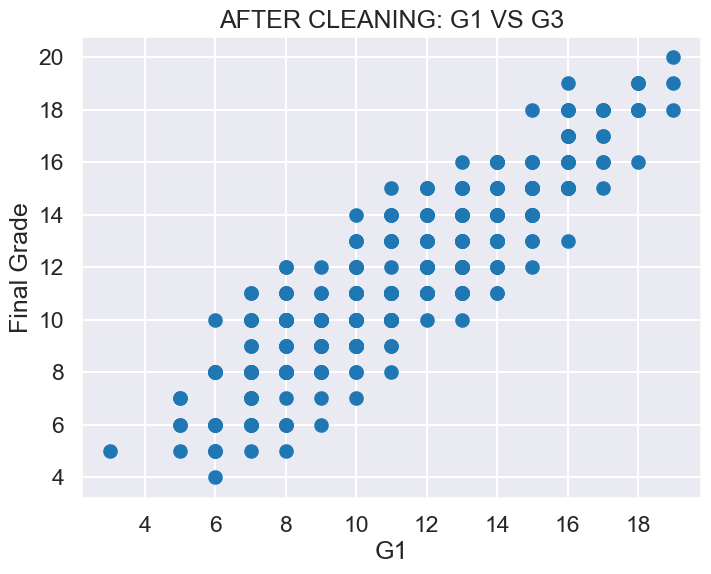

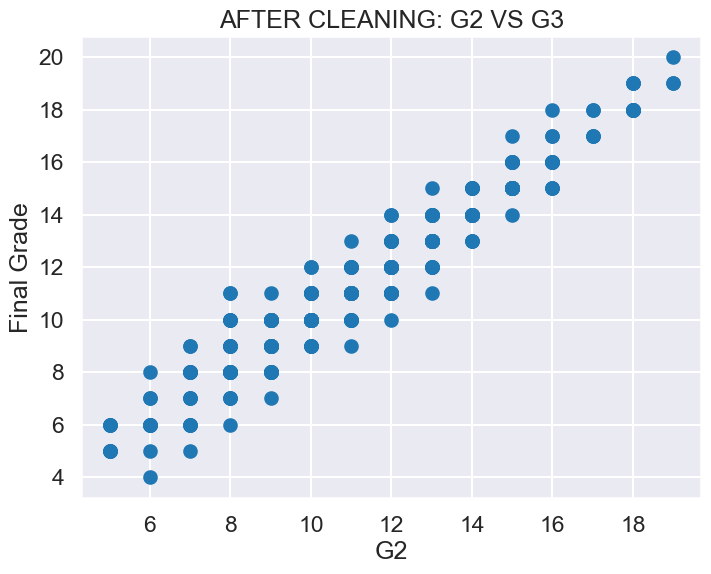

In [91]:
# First Grade and Second Grade AFTER CLEANING
pplot.figure(figsize=(8, 6))
pplot.scatter(data["G1"], data["G3"])
pplot.xlabel("G1")
pplot.ylabel("Final Grade")
pplot.title("AFTER CLEANING: G1 VS G3")

pplot.figure(figsize=(8, 6))
pplot.scatter(data["G2"], data["G3"])
pplot.xlabel("G2")
pplot.ylabel("Final Grade")
pplot.title("AFTER CLEANING: G2 VS G3")

Text(0.5, 1.0, 'Free Time VS Final Grade')

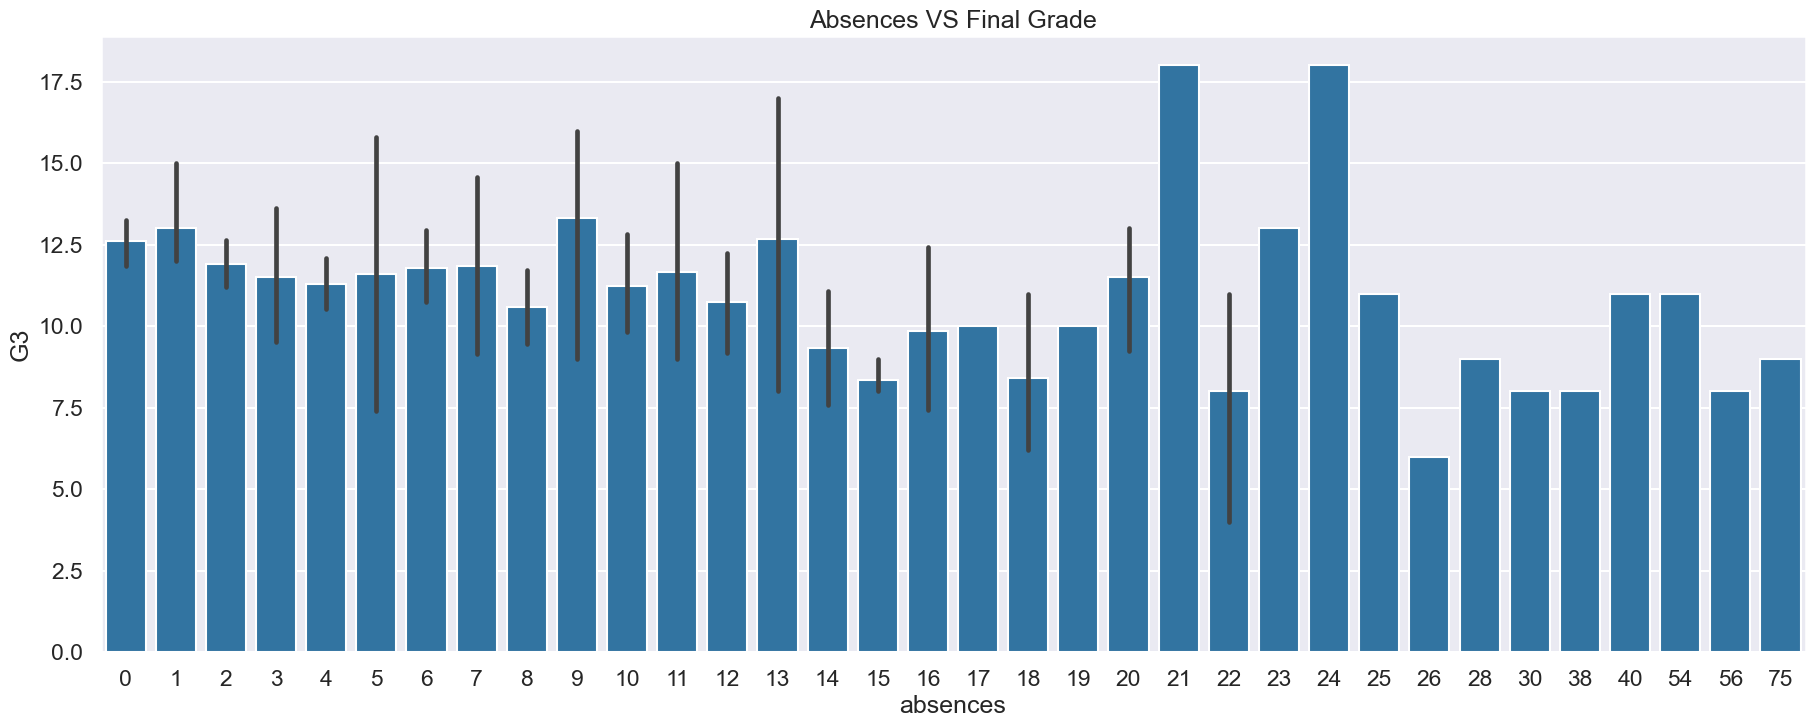

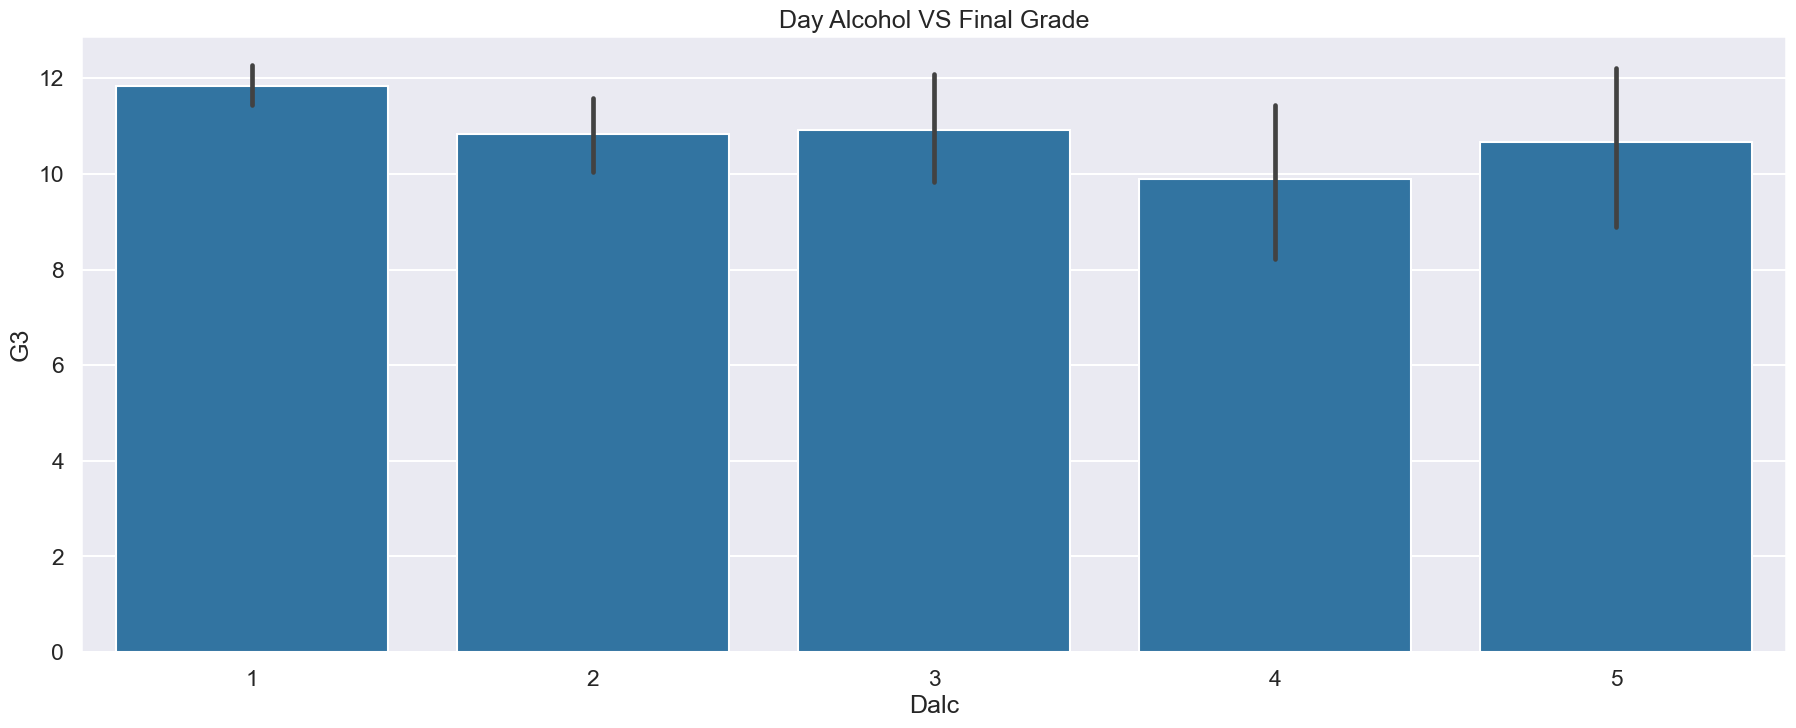

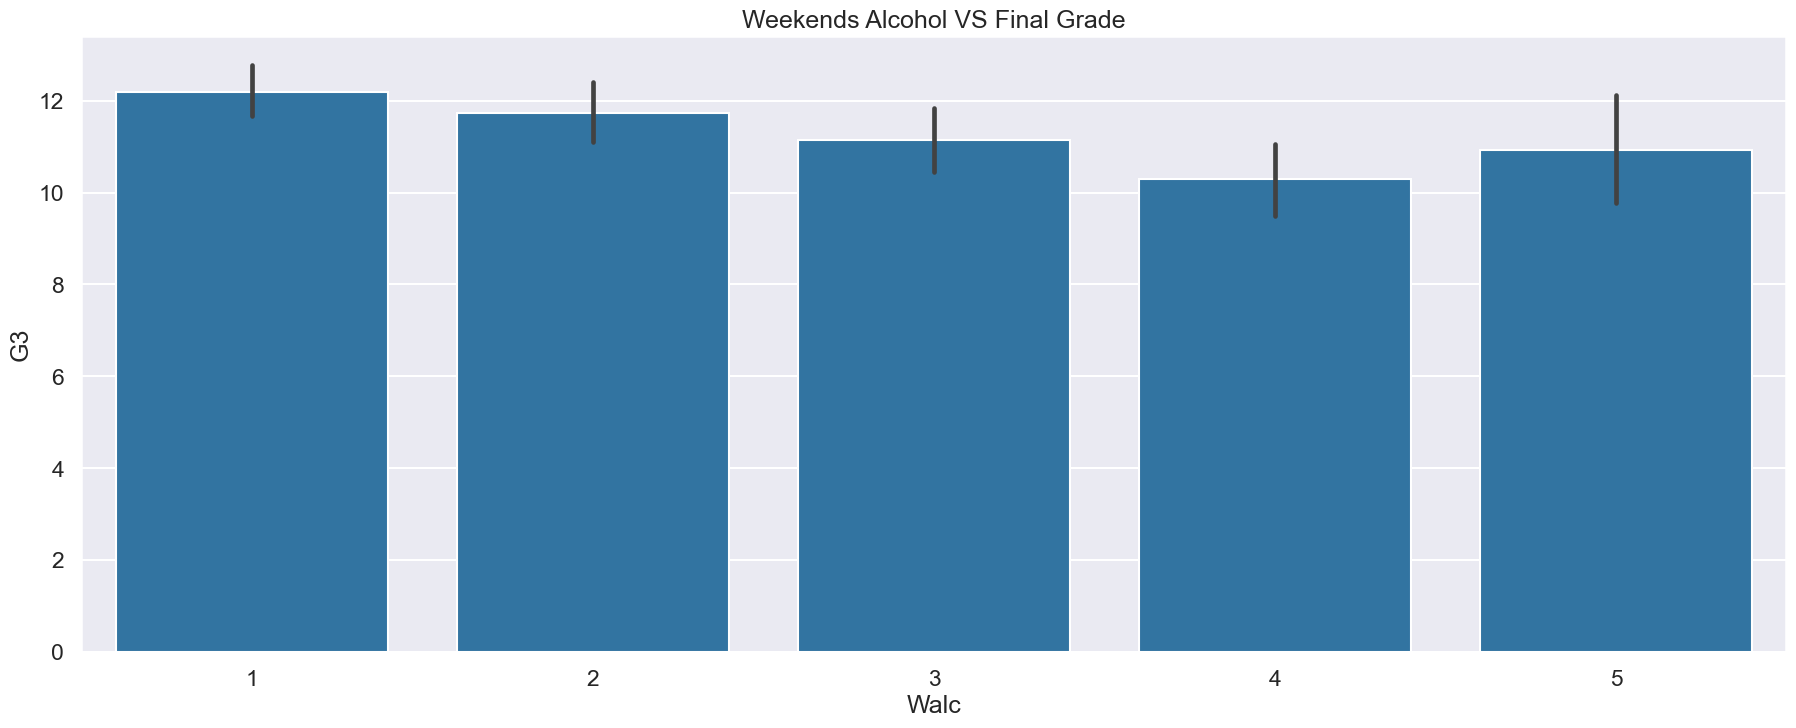

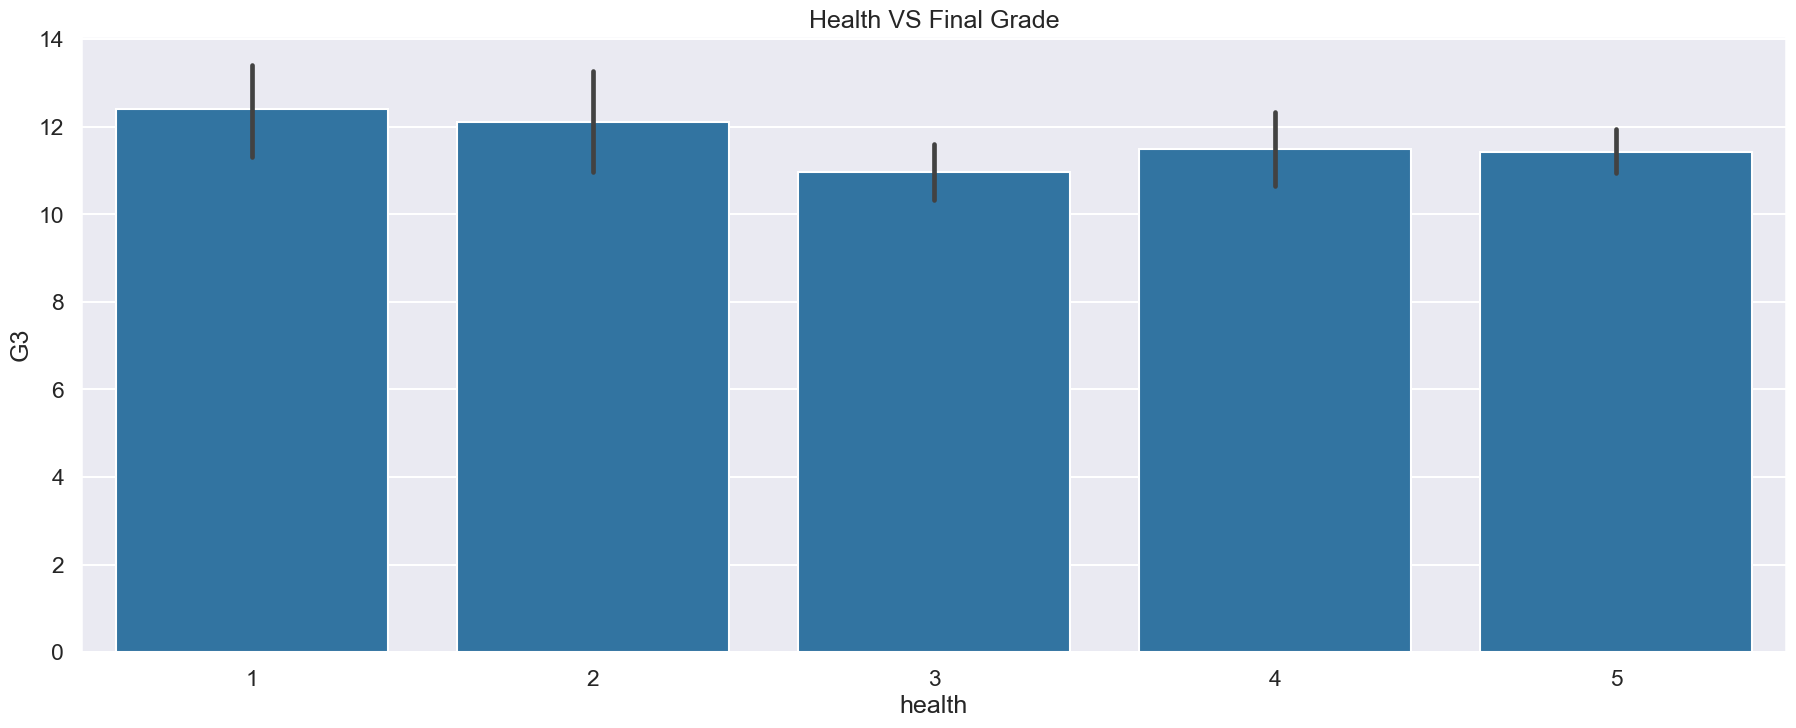

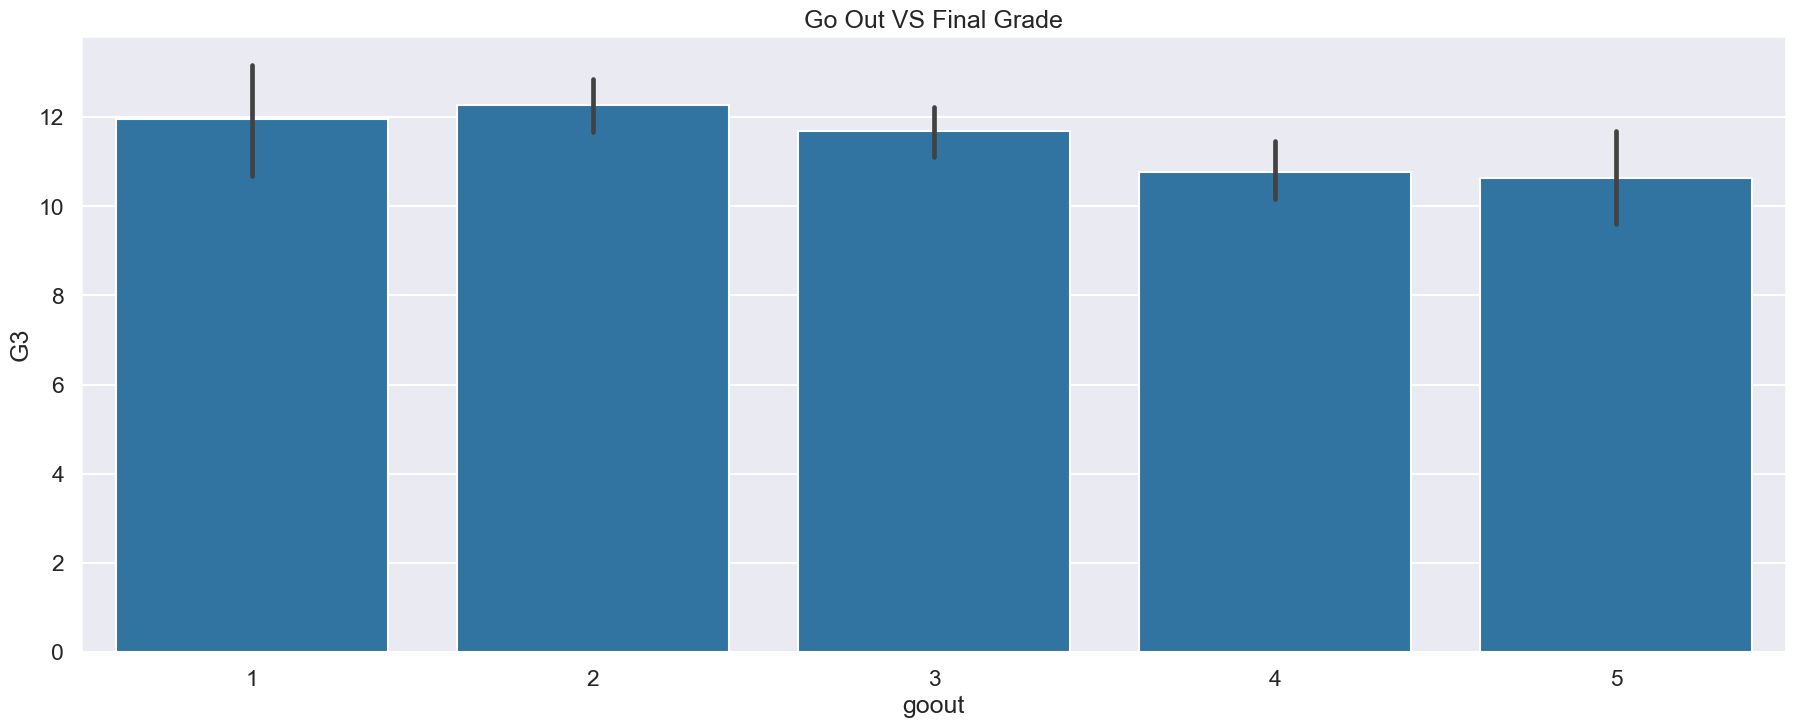

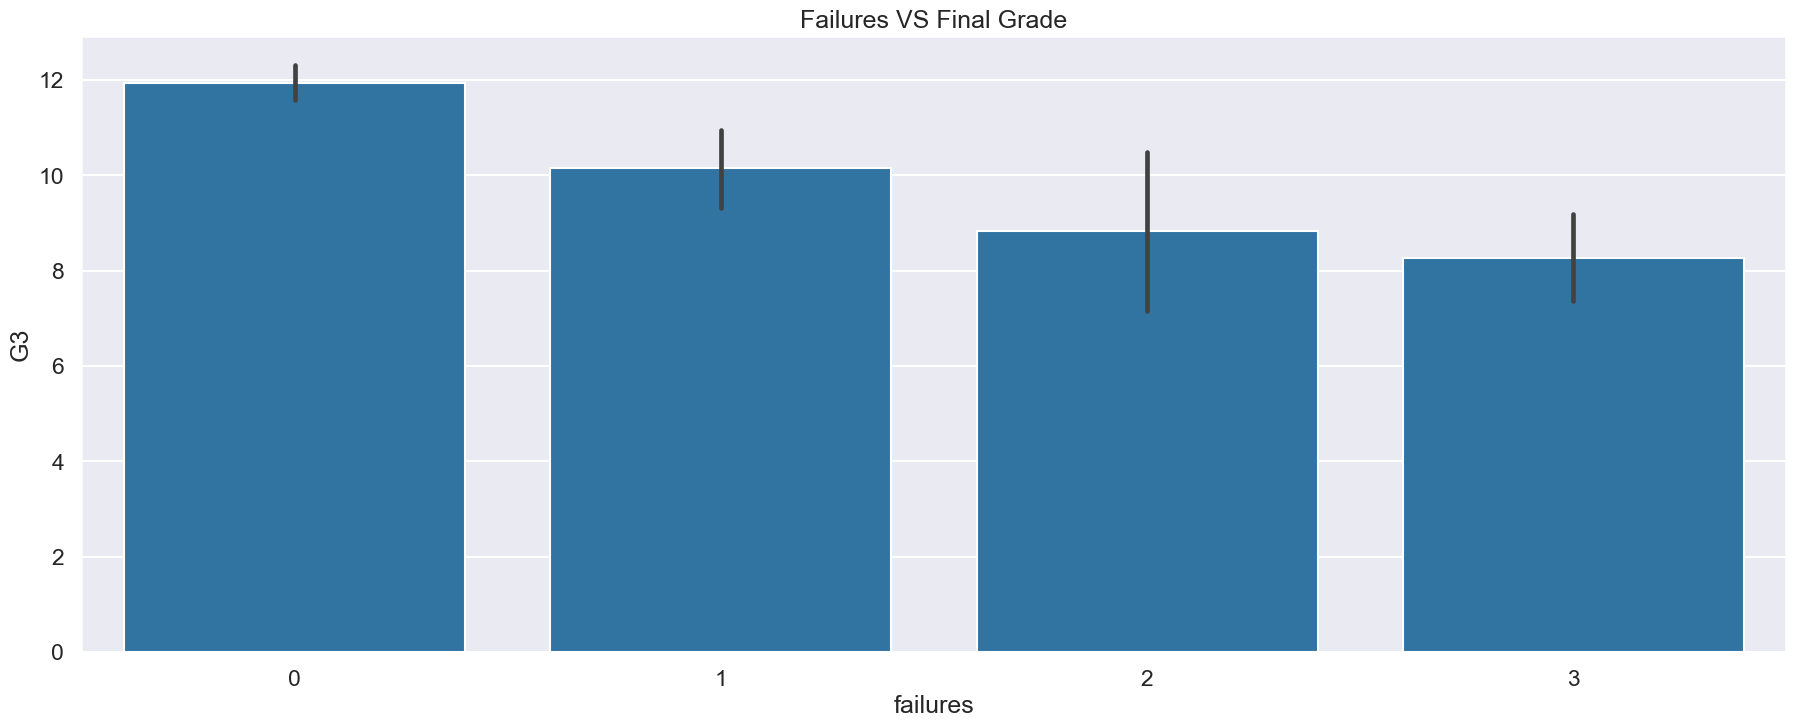

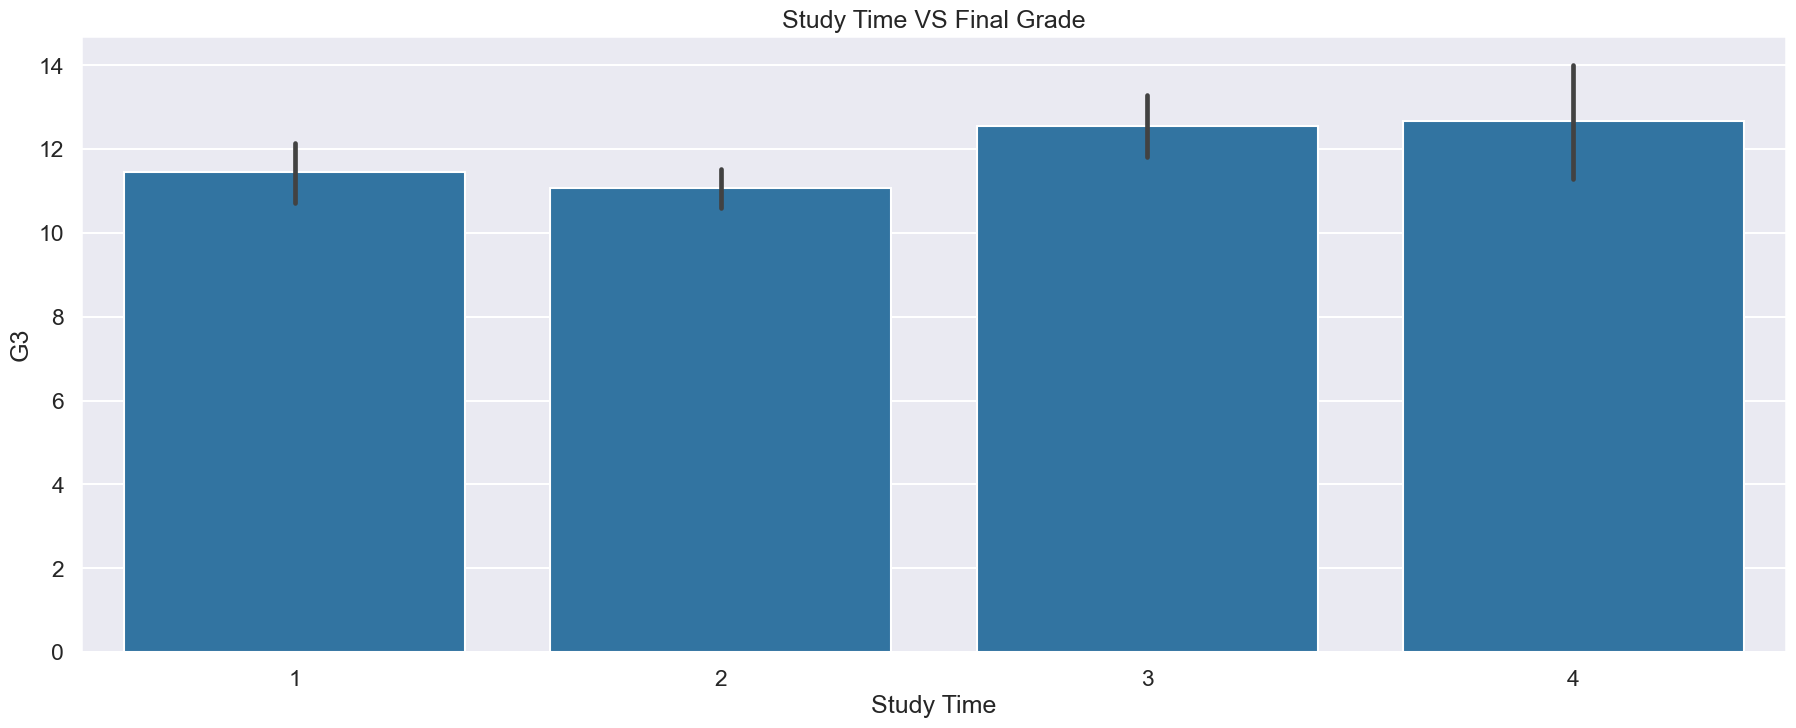

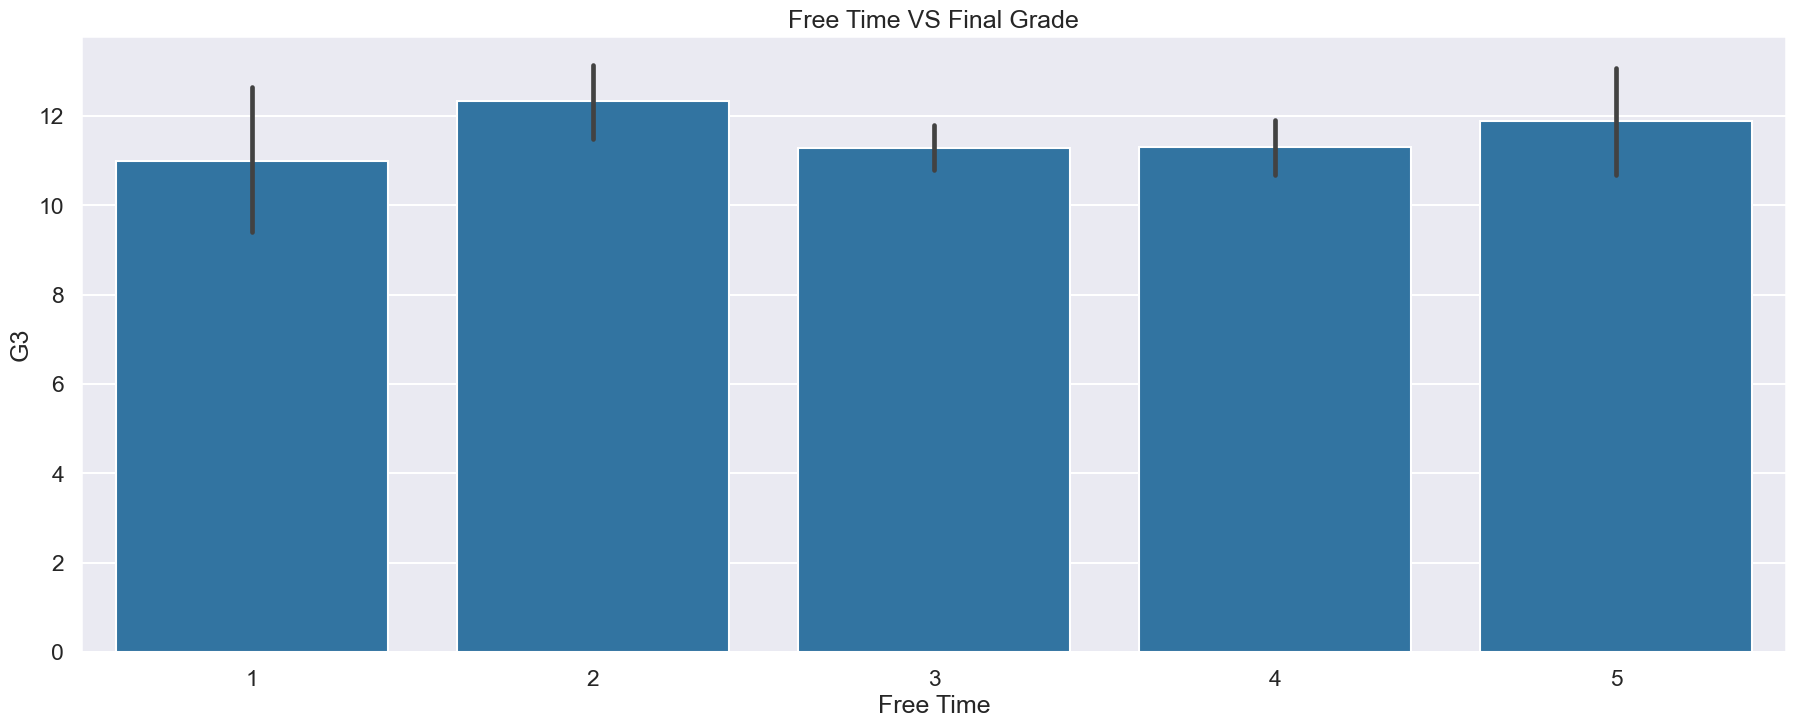

In [92]:
# Students' Lifestyle features VS Final Grade
pplot.figure(figsize=(22, 8))
sborn.barplot(x='absences', y='G3', data=data)
pplot.xlabel("absences")
pplot.ylabel("G3")
pplot.title("Absences VS Final Grade")

pplot.figure(figsize=(22, 8))
sborn.barplot(x='Dalc', y='G3', data=data)
pplot.xlabel("Dalc")
pplot.ylabel("G3")
pplot.title("Day Alcohol VS Final Grade")

pplot.figure(figsize=(22, 8))
sborn.barplot(x='Walc', y='G3', data=data)
pplot.xlabel("Walc")
pplot.ylabel("G3")
pplot.title("Weekends Alcohol VS Final Grade")

pplot.figure(figsize=(22, 8))
sborn.barplot(x='health', y='G3', data=data)
pplot.xlabel("health")
pplot.ylabel("G3")
pplot.title("Health VS Final Grade")

pplot.figure(figsize=(22, 8))
sborn.barplot(x='goout', y='G3', data=data)
pplot.xlabel("goout")
pplot.ylabel("G3")
pplot.title("Go Out VS Final Grade")

pplot.figure(figsize=(22, 8))
sborn.barplot(x='failures', y='G3', data=data)
pplot.xlabel("failures")
pplot.ylabel("G3")
pplot.title("Failures VS Final Grade")

pplot.figure(figsize=(22, 8))
sborn.barplot(x='studytime', y='G3', data=data)
pplot.xlabel("Study Time")
pplot.ylabel("G3")
pplot.title("Study Time VS Final Grade")

pplot.figure(figsize=(22, 8))
sborn.barplot(x='freetime', y='G3', data=data)
pplot.xlabel("Free Time")
pplot.ylabel("G3")
pplot.title("Free Time VS Final Grade")

Text(0.5, 1.0, 'Internet VS G3')

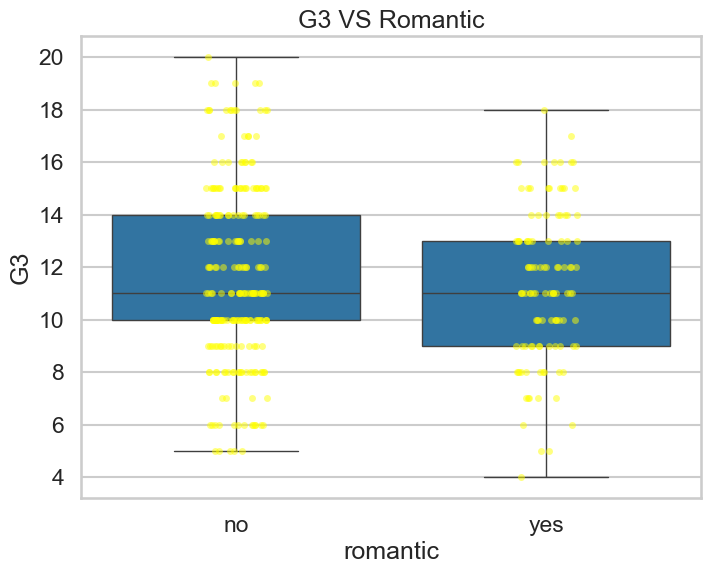

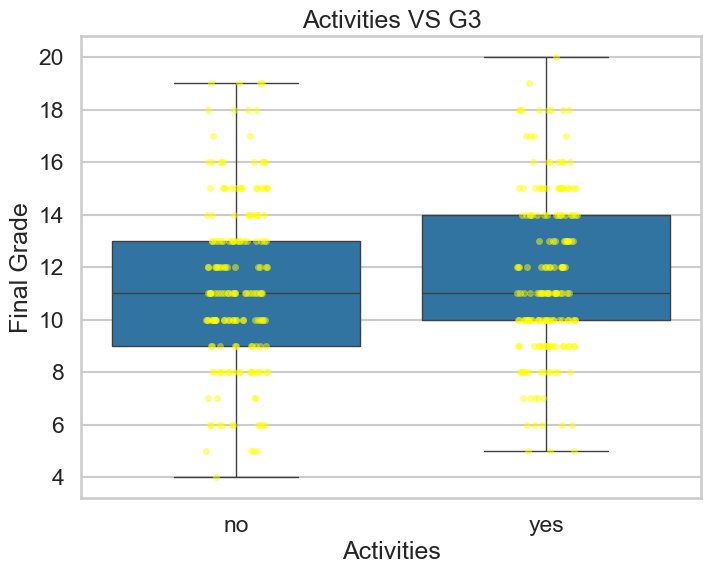

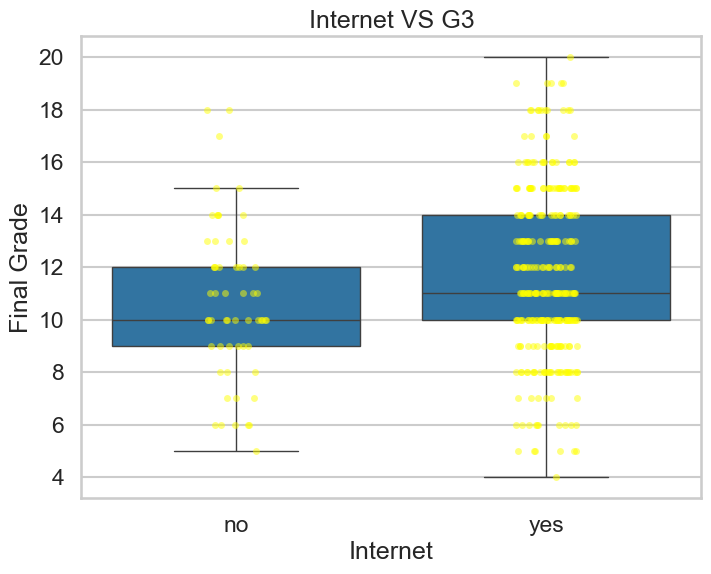

In [93]:
sborn.set_style("whitegrid")
sborn.set_context("talk")

pplot.figure(figsize=(8, 6))
roms_clean = data[data['G3'] > 0]
sborn.boxplot(x='romantic', y='G3', data=roms_clean, showfliers=False)
sborn.stripplot(x='romantic', y='G3', data=roms_clean, color='yellow', alpha=0.5)
pplot.title("G3 VS Romantic")

pplot.figure(figsize=(8, 6))
acts_clean = data[data['G3'] > 0]
sborn.boxplot(x='activities', y='G3', data=acts_clean, showfliers=False)
sborn.stripplot(x='activities', y='G3', data=acts_clean, color='yellow', alpha=0.5)
pplot.xlabel("Activities")
pplot.ylabel("Final Grade")
pplot.title("Activities VS G3")

pplot.figure(figsize=(8, 6))
ints_clean = data[data['G3'] > 0]
sborn.boxplot(x='internet', y='G3', data=ints_clean, showfliers=False)
sborn.stripplot(x='internet', y='G3', data=ints_clean, color='yellow', alpha=0.5)
pplot.xlabel("Internet")
pplot.ylabel("Final Grade")
pplot.title("Internet VS G3")